In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.weight_norm as weightNorm

import gc
import numpy as np
import scipy.signal
from concurrent.futures import ThreadPoolExecutor
from functools import lru_cache
from einops import rearrange
def SubBandSplit(data: np.ndarray, freq_start: int = 4, freq_end: int = 40, bandwidth: int = 4, fs: int = 250):
    """
    优化后的子带切分函数
    data(batch,channel,time) --> sub_band_data(batch,(channel*nBands),time)
    """
    @lru_cache(maxsize=32)
    def get_sos_coeffs(freq_low, freq_high, fs):
        """缓存并返回 SOS 滤波器系数"""
        return scipy.signal.butter(6, [2.0 * freq_low / fs, 2.0 * freq_high / fs], 'bandpass', output='sos')

    def process_single_band(args):
        """处理单个频带的数据"""
        data, freq_low, freq_high = args
        sos = get_sos_coeffs(freq_low, freq_high, fs)
        return scipy.signal.sosfilt(sos, data, axis=-1)

    subbands = np.arange(freq_start, freq_end + 1, bandwidth)
    with ThreadPoolExecutor() as executor:
        # 准备每个频带的参数
        band_args = [(data, low_freq, high_freq) 
                     for low_freq, high_freq in zip(subbands[:-1], subbands[1:])]
        # 并行处理每个频带
        results = list(executor.map(process_single_band, band_args))

    # 重塑结果以匹配所需的输出形状
    sub_band_data = np.stack(results, axis=1).astype(np.float32)
    del results
    gc.collect()
    # return rearrange(sub_band_data, 'b c t n -> b (c n) t')
    return sub_band_data


def init_weights(m):
    classname = m.__class__.__name__
    if classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)
    elif classname.find('Linear') != -1:
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)

#%% Support classes for FBNet Implementation
class VarLayer(nn.Module):
    '''
    The variance layer: calculates the variance of the data along given 'dim'
    '''
    def __init__(self, dim):
        super(VarLayer, self).__init__()
        self.dim = dim

    def forward(self, x):
        return x.var(dim = self.dim, keepdim= True)

class StdLayer(nn.Module):
    '''
    The standard deviation layer: calculates the std of the data along given 'dim'
    '''
    def __init__(self, dim):
        super(StdLayer, self).__init__()
        self.dim = dim

    def forward(self, x):
        return x.std(dim = self.dim, keepdim=True)

class LogVarLayer(nn.Module):
    '''
    The log variance layer: calculates the log variance of the data along given 'dim'
    (natural logarithm)
    '''
    def __init__(self, dim):
        super(LogVarLayer, self).__init__()
        self.dim = dim

    def forward(self, x):
        return torch.log(torch.clamp(x.var(dim = self.dim, keepdim= True), 1e-6, 1e6))

class MeanLayer(nn.Module):
    '''
    The mean layer: calculates the mean of the data along given 'dim'
    '''
    def __init__(self, dim):
        super(MeanLayer, self).__init__()
        self.dim = dim

    def forward(self, x):
        return x.mean(dim = self.dim, keepdim=True)

class MaxLayer(nn.Module):
    '''
    The max layer: calculates the max of the data along given 'dim'
    '''
    def __init__(self, dim):
        super(MaxLayer, self).__init__()
        self.dim = dim

    def forward(self, x):
        ma ,ima = x.max(dim = self.dim, keepdim=True)
        return ma

temporal_layer = {'VarLayer': VarLayer, 'StdLayer': StdLayer, 'LogVarLayer': LogVarLayer, 'MeanLayer': MeanLayer, 'MaxLayer': MaxLayer}

# Net: 1_2_3
class FBMSTSNet(nn.Module):

    def __init__(self, kernels, fs, temporalLayer = 'LogVarLayer', strideFactor= 5,
                    in_channels:int=22, nbands=12, num_classes=9, radix=8):
        super(FBMSTSNet, self).__init__()
        self.fs = fs
        self.kernels = kernels # type(List); conv_window kernels size
        self.parallel_conv = nn.ModuleList()
        self.strideFactor = strideFactor
        
        # 1D-parallel_conv
        for i, kernel_size in enumerate(list(self.kernels)):
            sep_conv = nn.Conv2d(in_channels=nbands, out_channels=nbands, kernel_size=(1,kernel_size),
                               stride=1, padding=0, bias=False, groups=nbands)
            self.parallel_conv.append(sep_conv)

        self.convblock = nn.Sequential(
            nn.BatchNorm2d(num_features=nbands),
            nn.ReLU(inplace=False),
            nn.Conv2d(in_channels=nbands, out_channels=nbands*radix, kernel_size=(in_channels,1),
                               stride=1, padding=0, bias=False)
            )
        
        self.temporalLayer = temporal_layer[temporalLayer](dim=-1)

        
        self.fc = nn.Sequential(
            nn.Linear(in_features=nbands*radix*strideFactor, out_features=num_classes),
            nn.LogSoftmax(dim=1)
        )
        
    
    def _get_fea_dim(self,x):
        with torch.no_grad():
            features, _ = self.forward(x)
        return features.shape

    def forward(self, x):
        # 为了在dataloader时统一expand_dims方便, 这里检查维度
        # x = x.squeeze(1) if x.dim() == 5 else x   # N, 1, nbands, C, T -> N, nbands, C, T
        x = torch.squeeze(x)
        device = x.device
        x = SubBandSplit(x.cpu().detach().numpy(), freq_start=8, freq_end=32, bandwidth=2, fs=self.fs)
        x = torch.from_numpy(x).to(device)
        out_sep = []
        # forward paralle 1D-conv blocks
        for i in range(len(self.kernels)):
            sep = self.parallel_conv[i](x)
            out_sep.append(sep)
        out = torch.cat(out_sep, dim=-1)
        out = self.convblock(out)
        out = torch.squeeze(out) # N, C', T'

        pad_length = self.strideFactor - (out.shape[-1] % self.strideFactor)
        if pad_length != 0:
            out = F.pad(out, (0, pad_length))

        out = out.reshape([*out.shape[0:2], self.strideFactor, int(out.shape[-1]/self.strideFactor)])
        out = self.temporalLayer(out)
        out = torch.flatten(out, start_dim=1)

        features = out
        return features, self.fc(features)

/home/hustmx709/.conda/envs/tyl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


weight shape: torch.Size([96, 12, 64, 1])


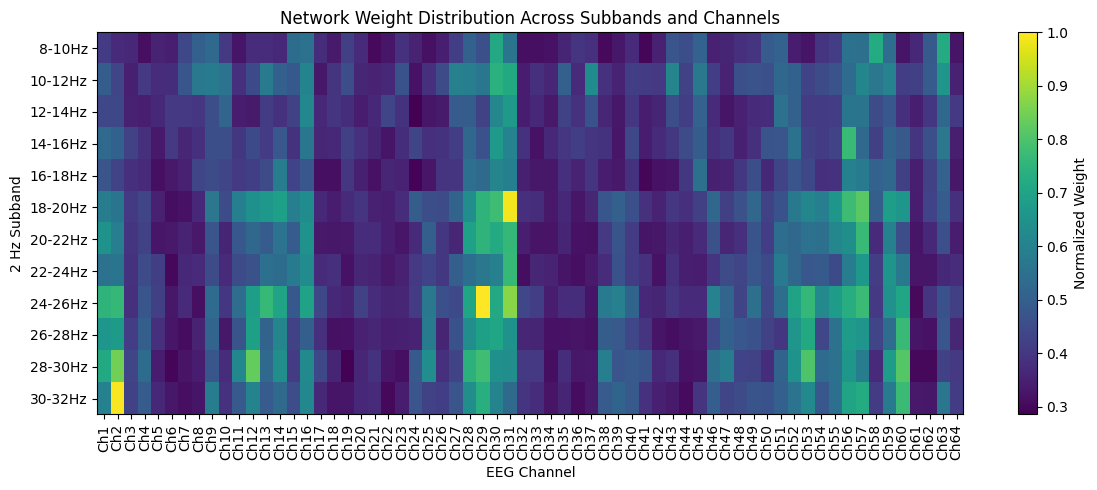

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 假设 weight 是 [out_channels, in_channels, kernel_h, kernel_w]
# 例如 weight = spatial_conv.weight.data.cpu().abs()
# 你的 nbands, in_channels, radix 已知

model = FBMSTSNet(kernels=[11,21,31,41,51], fs=250,num_classes=20, in_channels=64, nbands=12)
path = "/mnt/data1/tyl/UserID/ModelSave/M3CV_Motor/CELabelSmooth_FBMSTSNet_2024.pth"
model.load_state_dict(torch.load(path, map_location='cpu'))

spatial_conv = model.convblock[2]  # Conv2d: [out_channels, in_channels, kernel_h, kernel_w]
weight = spatial_conv.weight.data.cpu().abs()  # shape: [nbands*radix, nbands, in_channels, 1]
print(f'weight shape: {weight.shape}')

nbands = weight.shape[1]
in_channels = weight.shape[2]

heatmap = weight.sum(dim=0).squeeze()    # [12, 64]

# 归一化到0~1
heatmap = heatmap / heatmap.max()

# 标签
band_labels = [f'{8+2*i}-{10+2*i}Hz' for i in range(nbands)]
chan_labels = [f'Ch{i+1}' for i in range(in_channels)]

plt.figure(figsize=(12, 5))
im = plt.imshow(heatmap, aspect='auto', cmap='viridis')
plt.colorbar(im, label='Normalized Weight')
plt.xticks(np.arange(in_channels), chan_labels, rotation=90)
plt.yticks(np.arange(nbands), band_labels)
plt.xlabel('EEG Channel')
plt.ylabel('2 Hz Subband')
plt.title('Network Weight Distribution Across Subbands and Channels')
plt.tight_layout()
plt.show()